# Notebook 3: Embeddings & Semantic Similarity
## TF-IDF + Sentence-Transformer Representations

This notebook implements:
1. **TF-IDF vectorization** of extracted skill sets (classical approach per Aggarwal & Zhai, 2012)
2. **Sentence-transformer embeddings** using `all-MiniLM-L6-v2` for semantic similarity
3. **Cosine similarity computation** between resume and job skill representations
4. **Similarity distribution analysis** for understanding alignment quality


In [2]:
from google.colab import drive
import os

# 1. Mount the Drive
drive.mount('/content/drive')

# 2. Define your actual Drive project path
drive_path = '/content/drive/MyDrive/Colab Notebooks/DM_project_1'

# 3. Create the symbolic links
# This links the 'data', 'models', and 'outputs' folders from Drive to your local Colab env
folders = ['data', 'models', 'outputs']

for folder in folders:
    source = os.path.join(drive_path, folder)
    link = f'/content/{folder}'

    # Remove existing local folder/link if it exists to avoid errors
    if os.path.exists(link) or os.path.islink(link):
        !rm -rf {link}

    # Create the link (Shortcut)
    !ln -s "{source}" "{link}"
    print(f"✅ Linked local '{folder}/' to Drive '{folder}/'")

Mounted at /content/drive
✅ Linked local 'data/' to Drive 'data/'
✅ Linked local 'models/' to Drive 'models/'
✅ Linked local 'outputs/' to Drive 'outputs/'


In [3]:
# ============================================================
# Setup
# ============================================================
import os
import json
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import warnings
warnings.filterwarnings('ignore')

# Load data from previous notebooks
df_jobs = pd.read_csv('data/processed/jobs_with_skills.csv')
df_resumes = pd.read_csv('data/processed/resumes_with_skills.csv')

with open('data/processed/column_config.json') as f:
    col_config = json.load(f)
with open('data/processed/skill_category_map.json') as f:
    skill_category_map = json.load(f)
with open('data/processed/extraction_results.pkl', 'rb') as f:
    extraction_data = pickle.load(f)

# Parse extracted skills from JSON strings
df_jobs['skills_list'] = df_jobs['extracted_skills'].apply(json.loads)
df_resumes['skills_list'] = df_resumes['extracted_skills'].apply(json.loads)

cat_col = col_config['resume_cat_col']
title_col = col_config['jobs_title_col']

print(f"Loaded {len(df_jobs)} jobs, {len(df_resumes)} resumes")


Loaded 813 jobs, 106 resumes


## 1. TF-IDF Vectorization

We create TF-IDF vectors from the extracted skill sets. Each document is represented as a space-separated string of its canonical skill names. This follows classical text representation approaches (Aggarwal & Zhai, 2012).


In [4]:
# ============================================================
# 1. TF-IDF Vectorization
# ============================================================

# Convert skill lists to space-separated strings for TF-IDF
df_jobs['skills_text'] = df_jobs['skills_list'].apply(lambda x: ' '.join(x) if x else '')
df_resumes['skills_text'] = df_resumes['skills_list'].apply(lambda x: ' '.join(x) if x else '')

# Also create TF-IDF from the full processed text for richer representation
# Fit on combined corpus for shared vocabulary
all_skill_texts = list(df_jobs['skills_text']) + list(df_resumes['skills_text'])

# TF-IDF on extracted skills
tfidf_skills = TfidfVectorizer(max_features=500, ngram_range=(1, 3))
tfidf_skills.fit(all_skill_texts)

jobs_tfidf_skills = tfidf_skills.transform(df_jobs['skills_text'])
resumes_tfidf_skills = tfidf_skills.transform(df_resumes['skills_text'])

print(f"TF-IDF (skills only):")
print(f"  Vocabulary size: {len(tfidf_skills.vocabulary_)}")
print(f"  Jobs matrix: {jobs_tfidf_skills.shape}")
print(f"  Resumes matrix: {resumes_tfidf_skills.shape}")

# TF-IDF on full processed descriptions (for richer context)
all_full_texts = (list(df_jobs.get('processed_description', df_jobs.get('clean_description', ['']))) +
                  list(df_resumes.get('processed_resume', df_resumes.get('clean_resume', ['']))))

tfidf_full = TfidfVectorizer(max_features=2000, ngram_range=(1, 2), min_df=2, max_df=0.95)
tfidf_full.fit([str(t) for t in all_full_texts])

jobs_tfidf_full = tfidf_full.transform(
    [str(t) for t in df_jobs.get('processed_description', df_jobs.get('clean_description', ['']))])
resumes_tfidf_full = tfidf_full.transform(
    [str(t) for t in df_resumes.get('processed_resume', df_resumes.get('clean_resume', ['']))])

print(f"\nTF-IDF (full text):")
print(f"  Vocabulary size: {len(tfidf_full.vocabulary_)}")
print(f"  Jobs matrix: {jobs_tfidf_full.shape}")
print(f"  Resumes matrix: {resumes_tfidf_full.shape}")

# Top TF-IDF terms
feature_names = tfidf_skills.get_feature_names_out()
avg_tfidf = np.asarray(jobs_tfidf_skills.mean(axis=0)).flatten()
top_indices = avg_tfidf.argsort()[-15:][::-1]
print(f"\nTop 15 TF-IDF skill terms (by avg weight in jobs):")
for i in top_indices:
    print(f"  {feature_names[i]}: {avg_tfidf[i]:.4f}")


TF-IDF (skills only):
  Vocabulary size: 500
  Jobs matrix: (813, 500)
  Resumes matrix: (106, 500)

TF-IDF (full text):
  Vocabulary size: 2000
  Jobs matrix: (813, 2000)
  Resumes matrix: (106, 2000)

Top 15 TF-IDF skill terms (by avg weight in jobs):
  data: 0.1051
  analysis: 0.0785
  sql: 0.0612
  learning: 0.0587
  python: 0.0552
  data analysis: 0.0538
  communication: 0.0529
  teamwork: 0.0502
  apache: 0.0422
  etl: 0.0405
  machine learning: 0.0400
  machine: 0.0400
  statistical: 0.0399
  statistical analysis: 0.0399
  research: 0.0383


## 2. Sentence-Transformer Embeddings

We use `all-MiniLM-L6-v2` to generate dense semantic embeddings. This captures semantic relationships between skills that TF-IDF misses (e.g., "PyTorch" and "deep learning" are semantically related even though they're different tokens).


In [5]:
# ============================================================
# 2. Sentence-Transformer Embeddings
# ============================================================
from sentence_transformers import SentenceTransformer

model = SentenceTransformer('all-MiniLM-L6-v2')
print(f"Model loaded: all-MiniLM-L6-v2")
print(f"Embedding dimension: {model.get_sentence_embedding_dimension()}")

# Embed skill sets (as comma-separated strings for better semantic context)
jobs_skill_sentences = df_jobs['skills_list'].apply(
    lambda x: ', '.join(x) if x else 'no skills listed'
).tolist()
resumes_skill_sentences = df_resumes['skills_list'].apply(
    lambda x: ', '.join(x) if x else 'no skills listed'
).tolist()

print("\nEncoding job skill sets...")
jobs_embeddings = model.encode(jobs_skill_sentences, show_progress_bar=True, batch_size=64)
print("Encoding resume skill sets...")
resumes_embeddings = model.encode(resumes_skill_sentences, show_progress_bar=True, batch_size=64)

print(f"\nJob embeddings shape: {jobs_embeddings.shape}")
print(f"Resume embeddings shape: {resumes_embeddings.shape}")

# Also embed full descriptions for richer matching
print("\nEncoding full job descriptions...")
jobs_desc_texts = [str(t)[:512] for t in df_jobs.get('clean_description', df_jobs.iloc[:, 1])]
jobs_full_embeddings = model.encode(jobs_desc_texts, show_progress_bar=True, batch_size=64)

print("Encoding full resume texts...")
resumes_desc_texts = [str(t)[:512] for t in df_resumes.get('clean_resume', df_resumes.iloc[:, 1])]
resumes_full_embeddings = model.encode(resumes_desc_texts, show_progress_bar=True, batch_size=64)

print(f"\nFull description embeddings:")
print(f"  Jobs: {jobs_full_embeddings.shape}")
print(f"  Resumes: {resumes_full_embeddings.shape}")


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...


Job embeddings shape: (813, 384)
Resume embeddings shape: (106, 384)

Encoding full job descriptions...


Batches:   0%|          | 0/13 [00:00<?, ?it/s]

Encoding full resume texts...


Batches:   0%|          | 0/2 [00:00<?, ?it/s]


Full description embeddings:
  Jobs: (813, 384)
  Resumes: (106, 384)


In [6]:
# ============================================================
# 3. Individual Skill Embeddings (for fine-grained matching)
# ============================================================

# Embed each unique canonical skill for skill-level similarity
all_canonical_skills = list(skill_category_map.keys())
print(f"Embedding {len(all_canonical_skills)} individual canonical skills...")

skill_embeddings_dict = {}
skill_texts = all_canonical_skills
skill_vectors = model.encode(skill_texts, show_progress_bar=True, batch_size=64)

for skill, vec in zip(all_canonical_skills, skill_vectors):
    skill_embeddings_dict[skill] = vec

print(f"✅ Individual skill embeddings computed: {len(skill_embeddings_dict)} skills")

# Quick sanity check: find most similar skills to "machine learning"
if 'machine learning' in skill_embeddings_dict:
    ml_vec = skill_embeddings_dict['machine learning'].reshape(1, -1)
    all_vecs = np.array([skill_embeddings_dict[s] for s in all_canonical_skills])
    sims = cosine_similarity(ml_vec, all_vecs)[0]
    top_indices = sims.argsort()[-6:][::-1]
    print(f"\nMost similar skills to 'machine learning':")
    for i in top_indices:
        print(f"  {all_canonical_skills[i]}: {sims[i]:.4f}")


Embedding 121 individual canonical skills...


Batches:   0%|          | 0/2 [00:00<?, ?it/s]

✅ Individual skill embeddings computed: 121 skills

Most similar skills to 'machine learning':
  machine learning: 1.0000
  supervised learning: 0.7598
  deep learning: 0.6887
  reinforcement learning: 0.6364
  data analysis: 0.5545
  data modeling: 0.5449


## 3. Cosine Similarity Computation

We compute similarity between resumes and jobs using both TF-IDF and sentence-transformer representations. This dual approach lets us compare classical vs. semantic matching.


In [7]:
# ============================================================
# 4. Compute Similarity Matrices
# ============================================================

# Skill-based TF-IDF similarity
print("Computing TF-IDF skill similarity matrix...")
sim_tfidf_skills = cosine_similarity(resumes_tfidf_skills, jobs_tfidf_skills)
print(f"  Shape: {sim_tfidf_skills.shape} (resumes x jobs)")

# Sentence-transformer skill similarity
print("Computing sentence-transformer skill similarity...")
sim_sbert_skills = cosine_similarity(resumes_embeddings, jobs_embeddings)
print(f"  Shape: {sim_sbert_skills.shape}")

# Full-text sentence-transformer similarity
print("Computing full-text semantic similarity...")
sim_sbert_full = cosine_similarity(resumes_full_embeddings, jobs_full_embeddings)
print(f"  Shape: {sim_sbert_full.shape}")

# Combined similarity (weighted average)
WEIGHT_TFIDF = 0.3
WEIGHT_SBERT_SKILLS = 0.4
WEIGHT_SBERT_FULL = 0.3

sim_combined = (WEIGHT_TFIDF * sim_tfidf_skills +
                WEIGHT_SBERT_SKILLS * sim_sbert_skills +
                WEIGHT_SBERT_FULL * sim_sbert_full)
print(f"\nCombined similarity (weights: TF-IDF={WEIGHT_TFIDF}, "
      f"SBERT-skills={WEIGHT_SBERT_SKILLS}, SBERT-full={WEIGHT_SBERT_FULL})")
print(f"  Shape: {sim_combined.shape}")

# Summary stats
for name, mat in [('TF-IDF Skills', sim_tfidf_skills),
                  ('SBERT Skills', sim_sbert_skills),
                  ('SBERT Full', sim_sbert_full),
                  ('Combined', sim_combined)]:
    print(f"\n{name}:")
    print(f"  Mean: {mat.mean():.4f}")
    print(f"  Std:  {mat.std():.4f}")
    print(f"  Min:  {mat.min():.4f}")
    print(f"  Max:  {mat.max():.4f}")


Computing TF-IDF skill similarity matrix...
  Shape: (106, 813) (resumes x jobs)
Computing sentence-transformer skill similarity...
  Shape: (106, 813)
Computing full-text semantic similarity...
  Shape: (106, 813)

Combined similarity (weights: TF-IDF=0.3, SBERT-skills=0.4, SBERT-full=0.3)
  Shape: (106, 813)

TF-IDF Skills:
  Mean: 0.0487
  Std:  0.0733
  Min:  0.0000
  Max:  1.0000

SBERT Skills:
  Mean: 0.3929
  Std:  0.1817
  Min:  -0.1106
  Max:  1.0000

SBERT Full:
  Mean: 0.2402
  Std:  0.1096
  Min:  -0.1282
  Max:  0.6832

Combined:
  Mean: 0.2438
  Std:  0.0983
  Min:  -0.0207
  Max:  0.7906


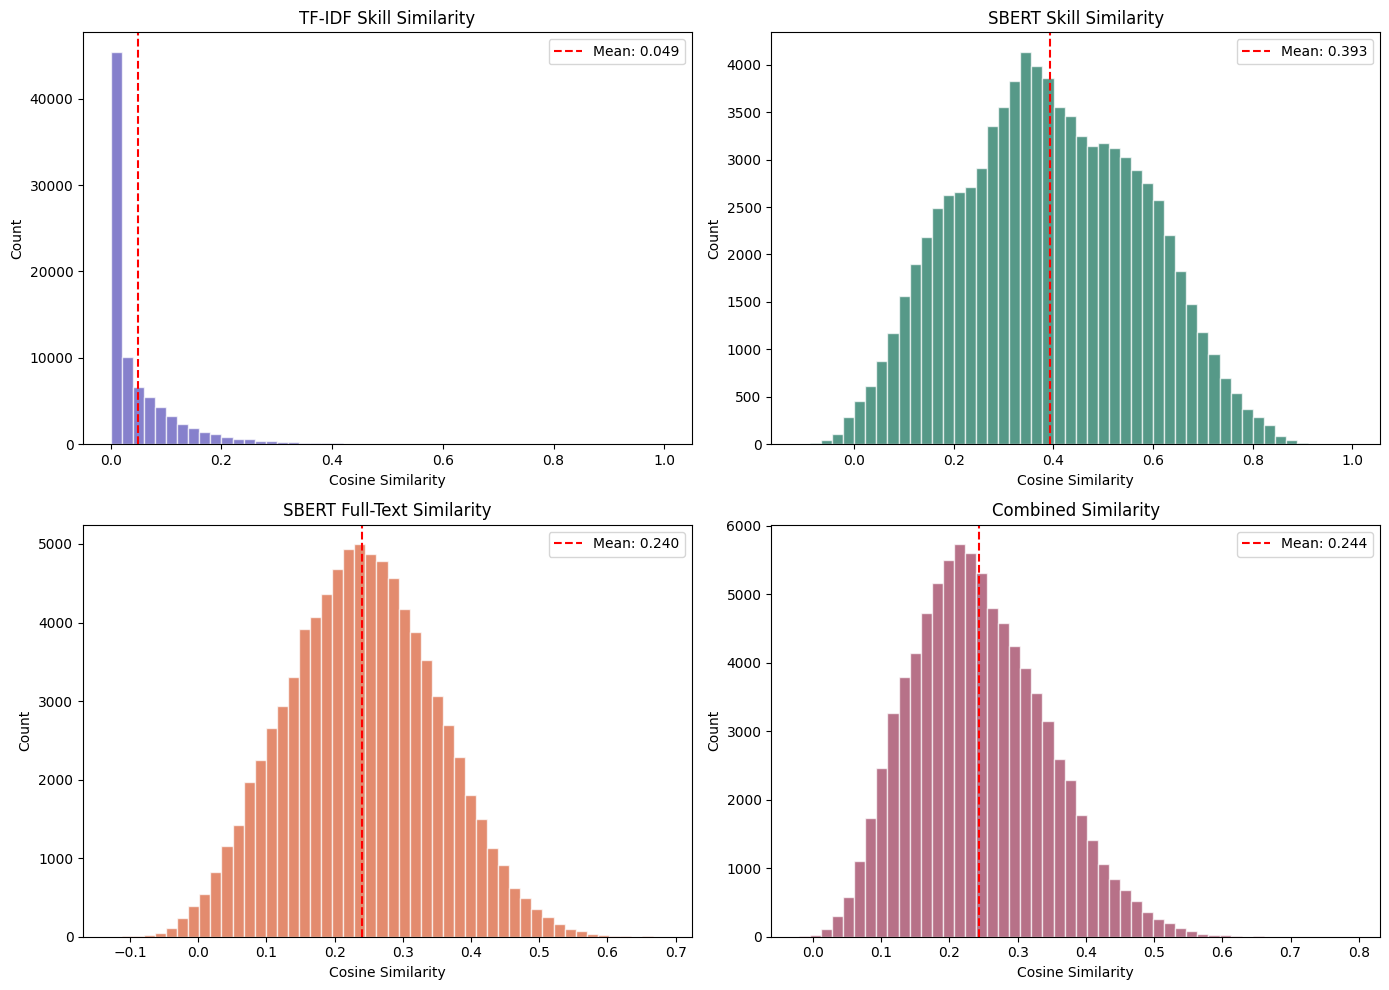

In [8]:
# ============================================================
# 5. Similarity Distribution Analysis
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

matrices = [
    ('TF-IDF Skill Similarity', sim_tfidf_skills, '#534AB7'),
    ('SBERT Skill Similarity', sim_sbert_skills, '#0F6E56'),
    ('SBERT Full-Text Similarity', sim_sbert_full, '#D85A30'),
    ('Combined Similarity', sim_combined, '#993556'),
]

for ax, (title, mat, color) in zip(axes.flat, matrices):
    # Sample to avoid memory issues with large matrices
    sample_vals = mat.flatten()
    if len(sample_vals) > 100000:
        sample_vals = np.random.choice(sample_vals, 100000, replace=False)
    ax.hist(sample_vals, bins=50, color=color, alpha=0.7, edgecolor='white')
    ax.set_title(title)
    ax.set_xlabel('Cosine Similarity')
    ax.set_ylabel('Count')
    ax.axvline(np.mean(sample_vals), color='red', linestyle='--',
               label=f'Mean: {np.mean(sample_vals):.3f}')
    ax.legend()

plt.tight_layout()
plt.savefig('outputs/03_similarity_distributions.png', dpi=150, bbox_inches='tight')
plt.show()


In [9]:
# ============================================================
# 6. Top Matches Analysis
# ============================================================

# For each resume, find the top 3 most similar jobs
print("Top matches (Combined Similarity):")
print("="*80)

# Show first 5 resumes and their top matches
n_show = min(5, len(df_resumes))
for i in range(n_show):
    top_job_indices = sim_combined[i].argsort()[-3:][::-1]
    resume_cat = df_resumes.iloc[i].get(cat_col, 'N/A')
    resume_skills = json.loads(df_resumes.iloc[i]['extracted_skills'])[:5]

    print(f"\nResume #{i} (Category: {resume_cat})")
    print(f"  Skills: {', '.join(resume_skills)}")
    print(f"  Top matching jobs:")
    for rank, j in enumerate(top_job_indices, 1):
        job_title = df_jobs.iloc[j].get(title_col, 'N/A')
        score = sim_combined[i, j]
        job_skills = json.loads(df_jobs.iloc[j]['extracted_skills'])[:5]
        print(f"    {rank}. [{score:.3f}] {job_title}")
        print(f"       Skills: {', '.join(job_skills)}")


Top matches (Combined Similarity):

Resume #0 (Category: Data Science)
  Skills: nltk, mysql, css, tableau, plotly
  Top matching jobs:
    1. [0.576] Data Scientist
       Skills: communication, deep learning, hadoop, scipy, python
    2. [0.574] Junior Data Scientist
       Skills: tableau, apache spark, deep learning, hadoop, python
    3. [0.567] AI / Machine Learning Engineer (early-career, on-site full time)
       Skills: scipy, python, docker, supervised learning, machine learning

Resume #1 (Category: Data Science)
  Skills: scikit-learn, research, aws, feature engineering, scipy
  Top matching jobs:
    1. [0.591] Data Scientist
       Skills: communication, etl, apache spark, feature engineering, deep learning
    2. [0.570] Machine Learning Engineer
       Skills: teamwork, communication, a/b testing, apache spark, plotly
    3. [0.564] Analyst, Data Science
       Skills: scikit-learn, model deployment, aws, sql, ci/cd

Resume #2 (Category: Data Science)
  Skills: mysql, j

In [10]:
# ============================================================
# 7. Save All Embeddings & Similarity Data
# ============================================================

embeddings_data = {
    'jobs_embeddings': jobs_embeddings,
    'resumes_embeddings': resumes_embeddings,
    'jobs_full_embeddings': jobs_full_embeddings,
    'resumes_full_embeddings': resumes_full_embeddings,
    'skill_embeddings_dict': skill_embeddings_dict,
    'sim_tfidf_skills': sim_tfidf_skills,
    'sim_sbert_skills': sim_sbert_skills,
    'sim_sbert_full': sim_sbert_full,
    'sim_combined': sim_combined,
    'weights': {
        'tfidf': WEIGHT_TFIDF,
        'sbert_skills': WEIGHT_SBERT_SKILLS,
        'sbert_full': WEIGHT_SBERT_FULL,
    }
}

with open('data/processed/embeddings_data.pkl', 'wb') as f:
    pickle.dump(embeddings_data, f)

# Save TF-IDF models
with open('models/tfidf_skills.pkl', 'wb') as f:
    pickle.dump(tfidf_skills, f)
with open('models/tfidf_full.pkl', 'wb') as f:
    pickle.dump(tfidf_full, f)

print("✅ All embeddings and similarity data saved!")
print(f"  data/processed/embeddings_data.pkl")
print(f"  models/tfidf_skills.pkl")
print(f"  models/tfidf_full.pkl")
print(f"\n{'='*60}")
print("PHASE 2b COMPLETE — Ready for Notebook 04: Skill Gap Analysis")
print(f"{'='*60}")


✅ All embeddings and similarity data saved!
  data/processed/embeddings_data.pkl
  models/tfidf_skills.pkl
  models/tfidf_full.pkl

PHASE 2b COMPLETE — Ready for Notebook 04: Skill Gap Analysis
